In [8]:
import pandas as pd
import numpy as np
import os
from glob import glob
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, make_scorer, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, RepeatedStratifiedKFold
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

## Flattening the upper triangle of Pearson Correlation Coefficient matric for edge features

In [9]:
base_dir = "./PCC"
groups = ["AD", "CN"]
all_subjects = []

for label in groups:
    folder_path = os.path.join(base_dir, label)

    files = glob(os.path.join(folder_path, "*.mat"))


    for file_path in files:

        mat_data = loadmat(file_path)
        matrix = mat_data["ROICorrelation"]

        matrix = np.abs(matrix)

        rows, cols = matrix.shape
        if rows != cols:
            print(f"Skipping {file_path}, shape={matrix.shape}")
            continue

        upper_idx = np.triu_indices(rows, k=1)
        edge_values = matrix[upper_idx]

        subject_name = os.path.splitext(os.path.basename(file_path))[0]

        row = {"Subject": subject_name}

        for i, val in enumerate(edge_values):
            row[f"Edge{i+1}"] = val

        row["Label"] = label

        all_subjects.append(row)

final_df = pd.DataFrame(all_subjects)
final_df.to_csv("edge_features_abs.csv", index=False)

print(final_df.head())

print("Shape:", final_df.shape)

      Subject     Edge1     Edge2     Edge3     Edge4     Edge5     Edge6  \
0  019_S_4549  0.758790  0.150282  0.303784  0.619776  0.354481  0.733343   
1  006_S_4546  0.881795  0.182629  0.145910  0.831929  0.855930  0.665108   
2  018_S_4733  0.912633  0.920054  0.922906  0.842510  0.795526  0.953958   
3  010_S_5163  0.598481  0.657425  0.518153  0.636618  0.757823  0.735866   
4  006_S_4153  0.119583  0.568207  0.540794  0.598755  0.723425  0.355085   

      Edge7     Edge8     Edge9  ...   Edge317   Edge318   Edge319   Edge320  \
0  0.721399  0.674049  0.519178  ...  0.152020  0.579337  0.410625  0.153179   
1  0.688868  0.030365  0.272161  ...  0.172168  0.172606  0.112883  0.034127   
2  0.859986  0.913524  0.746371  ...  0.787297  0.242460  0.197093  0.225871   
3  0.817814  0.610448  0.767144  ...  0.615342  0.185741  0.101365  0.189327   
4  0.312130  0.492416  0.566623  ...  0.074058  0.030809  0.564630  0.107952   

    Edge321   Edge322   Edge323   Edge324   Edge325  Lab

## Finding optimal K value for Mann-Whitney U test (K-value vs Random Forest Accuracy)

In [10]:
df_raw = final_df.copy()
df_z = pd.read_csv("edge_features_z.csv")


feature_names = df_raw.drop(columns=["Subject", "Label"]).columns

X_raw = df_raw.drop(columns=["Subject", "Label"]).values
X_z = df_z.drop(columns=["Subject", "Label"]).values
y = df_raw["Label"].values


label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)


k_values = list(range(10, 101, 5))

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

cv_splits = list(cv.split(X_raw, y))

accuracy_dict = {}
edge_stability = {}


for K in k_values:
    print(f"\nRunning K={K}")
    fold_accuracies = []

    edge_frequency = np.zeros(X_raw.shape[1], dtype=int)
    for fold, (train_idx, test_idx) in enumerate(cv_splits,start=1):
        X_train_raw = X_raw[train_idx]
        X_test_raw = X_raw[test_idx]

        X_train_z = X_z[train_idx]
        X_test_z = X_z[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        class0 = (y_train == 0)
        class1 = (y_train == 1)

        mwu_scores = []
        for f in range(X_raw.shape[1]):
            group0 = X_train_raw[class0, f]
            group1 = X_train_raw[class1, f]

            _, p_value = mannwhitneyu(group0, group1,alternative="two-sided")
            score = -np.log10(p_value + 1e-10)
            mwu_scores.append(score)

        mwu_scores = np.array(mwu_scores)

        top_features = np.argsort(mwu_scores)[-K:]
        edge_frequency[top_features] += 1

        X_train_selected = X_train_z[:, top_features]
        X_test_selected = X_test_z[:, top_features]

        rf = RandomForestClassifier(n_estimators=200, random_state=42)
        rf.fit(X_train_selected, y_train)

        y_pred = rf.predict(X_test_selected)
        acc = accuracy_score(y_test, y_pred)
        fold_accuracies.append(acc)

        print(f"\nK={K}, Fold={fold}")
        print(f"Accuracy={acc:.4f}")
        print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))

    accuracy_dict[f"K_{K}"] = fold_accuracies
    edge_stability[f"K_{K}"] = edge_frequency

accuracy_df = pd.DataFrame(accuracy_dict)
accuracy_df.index = [f"Fold_{i}" for i in range(1, len(accuracy_df)+1)]
accuracy_df.to_csv("accuracy_vs_k.csv")
print("\nAccuracy table:")
print(accuracy_df)

mean_accuracy = accuracy_df.mean()
print("\nMean accuracy per K:")
print(mean_accuracy.sort_values(ascending=False))

best_k = mean_accuracy.idxmax()
print(f"\nBest K = {best_k}")
best_edge_frequency = edge_stability[best_k]

threshold = 25

stable_edges = pd.DataFrame({"Feature_Name": feature_names, "Frequency": best_edge_frequency})
stable_edges = stable_edges[stable_edges["Frequency"] > threshold]
stable_edges = stable_edges.sort_values(by="Frequency", ascending=False)
stable_edges.to_csv("stable_edges.csv", index=False)
print("\nStable edges (>50% folds):")
print(stable_edges.head(20))


Running K=10

K=10, Fold=1
Accuracy=0.6667
              precision    recall  f1-score   support

          AD     0.6667    0.5714    0.6154         7
          CN     0.6667    0.7500    0.7059         8

    accuracy                         0.6667        15
   macro avg     0.6667    0.6607    0.6606        15
weighted avg     0.6667    0.6667    0.6637        15


K=10, Fold=2
Accuracy=0.5714
              precision    recall  f1-score   support

          AD     0.5000    0.5000    0.5000         6
          CN     0.6250    0.6250    0.6250         8

    accuracy                         0.5714        14
   macro avg     0.5625    0.5625    0.5625        14
weighted avg     0.5714    0.5714    0.5714        14


K=10, Fold=3
Accuracy=0.7143
              precision    recall  f1-score   support

          AD     1.0000    0.3333    0.5000         6
          CN     0.6667    1.0000    0.8000         8

    accuracy                         0.7143        14
   macro avg     0.8333 

## Finding the optimised max_features value for Random Forest

In [15]:
df_raw = final_df.copy()
df_z = pd.read_csv("edge_features_z.csv")

feature_names = df_raw.drop(columns=["Subject", "Label"]).columns

X_raw = df_raw.drop(columns=["Subject", "Label"]).values
X_z = df_z.drop(columns=["Subject", "Label"]).values

y = df_raw["Label"].values

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

K = 30

threshold = 25

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)
cv_splits = list(cv.split(X_raw, y))

metric_results = []
all_feature_importances = []
all_stable_edges = []

for max_feat in range(2, 30):
    print(f"\nRunning RF with max_features={max_feat}")

    edge_frequency = np.zeros(X_raw.shape[1],dtype=int)

    fold_acc = []
    fold_prec = []
    fold_rec = []
    fold_auc = []
    fold_importances = []
    for fold, (train_idx, test_idx) in enumerate(cv_splits, start=1):
        X_train_raw = X_raw[train_idx]
        X_test_raw = X_raw[test_idx]

        X_train_z = X_z[train_idx]
        X_test_z = X_z[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        class0 = (y_train == 0)
        class1 = (y_train == 1)

        mwu_scores = []
        for f in range(X_raw.shape[1]):
            group0 = X_train_raw[class0, f]
            group1 = X_train_raw[class1, f]

            _, p_value = mannwhitneyu(group0,group1, alternative="two-sided")
            score = -np.log10(p_value + 1e-10)
            mwu_scores.append(score)

        mwu_scores = np.array(mwu_scores)

        ranked_features = np.argsort(mwu_scores)[::-1]
        top_features = ranked_features[:K]
        edge_frequency[top_features] += 1

        X_train_selected = X_train_z[:, top_features]
        X_test_selected = X_test_z[:, top_features]

        rf = RandomForestClassifier(n_estimators = 90, max_features=max_feat, random_state=42)
        rf.fit(X_train_selected, y_train)

        importance_df = pd.DataFrame({"Feature_Name": feature_names[top_features], "Importance": rf.feature_importances_, "Fold": fold})
        fold_importances.append(importance_df)

        y_pred = rf.predict(X_test_selected)
        y_prob = rf.predict_proba(X_test_selected)[:, 1]

        fold_acc.append(accuracy_score(y_test, y_pred))
        fold_prec.append(precision_score(y_test, y_pred, zero_division=0))
        fold_rec.append(recall_score(y_test, y_pred, zero_division=0))
        fold_auc.append(roc_auc_score(y_test, y_prob))

    metric_results.append({"max_features": max_feat, "accuracy": np.mean(fold_acc), "precision": np.mean(fold_prec), "recall": np.mean(fold_rec), "roc_auc": np.mean(fold_auc)})

    fold_importances = pd.concat(fold_importances,ignore_index=True)
    feature_importance_summary = (fold_importances.groupby(
        "Feature_Name")["Importance"].agg(
            Mean_Importance="mean",
            Std_Importance="std",
            Min_Importance="min",
            Max_Importance="max"
        ).reset_index().sort_values(
            by="Mean_Importance",
            ascending=False
        )
    )
    feature_importance_summary["max_features"] = max_feat
    feature_importance_summary.to_csv(f"./feature_importance/feature_importance_maxfeat_{max_feat}.csv", index=False)

    all_feature_importances.append(feature_importance_summary)

    stable_edges = pd.DataFrame({"Feature_Name": feature_names, "Frequency": edge_frequency})
    stable_edges = stable_edges[stable_edges["Frequency"] > threshold]
    stable_edges = stable_edges.merge(
        feature_importance_summary[
            [
                "Feature_Name",
                "Mean_Importance"
            ]
        ],
        on="Feature_Name",
        how="left"
    )
    stable_edges = stable_edges.sort_values(
        by=[
            "Frequency",
            "Mean_Importance"
        ],
        ascending=False
    )
    stable_edges["max_features"] = max_feat
    stable_edges.to_csv(f"./stable_features/stable_edges_maxfeat_{max_feat}.csv",index=False)
    all_stable_edges.append(stable_edges)

    print(f"Accuracy = {np.mean(fold_acc):.4f}")
    print(f"Precision = {np.mean(fold_prec):.4f}")
    print(f"Recall = {np.mean(fold_rec):.4f}")
    print(f"ROC-AUC = {np.mean(fold_auc):.4f}")

results_df = pd.DataFrame(metric_results)
results_df.to_csv("rf_metrics_vs_max_features.csv", index=False)

all_feature_importances = pd.concat(all_feature_importances, ignore_index=True)
all_feature_importances.to_csv("feature_importances_all_max_features.csv", index=False)
all_stable_edges = pd.concat(all_stable_edges,ignore_index=True)
all_stable_edges.to_csv("stable_edges_all_max_features.csv",index=False)


Running RF with max_features=2
Accuracy = 0.6407
Precision = 0.6607
Recall = 0.7625
ROC-AUC = 0.6828

Running RF with max_features=3
Accuracy = 0.6340
Precision = 0.6651
Recall = 0.7325
ROC-AUC = 0.6875

Running RF with max_features=4
Accuracy = 0.6403
Precision = 0.6649
Recall = 0.7650
ROC-AUC = 0.6807

Running RF with max_features=5
Accuracy = 0.6390
Precision = 0.6662
Recall = 0.7525
ROC-AUC = 0.6880

Running RF with max_features=6
Accuracy = 0.6329
Precision = 0.6617
Recall = 0.7375
ROC-AUC = 0.6752

Running RF with max_features=7
Accuracy = 0.6372
Precision = 0.6745
Recall = 0.7225
ROC-AUC = 0.6762

Running RF with max_features=8
Accuracy = 0.6307
Precision = 0.6628
Recall = 0.7200
ROC-AUC = 0.6625

Running RF with max_features=9
Accuracy = 0.6306
Precision = 0.6554
Recall = 0.7350
ROC-AUC = 0.6665

Running RF with max_features=10
Accuracy = 0.6222
Precision = 0.6578
Recall = 0.7175
ROC-AUC = 0.6588

Running RF with max_features=11
Accuracy = 0.6151
Precision = 0.6502
Recall = 0.

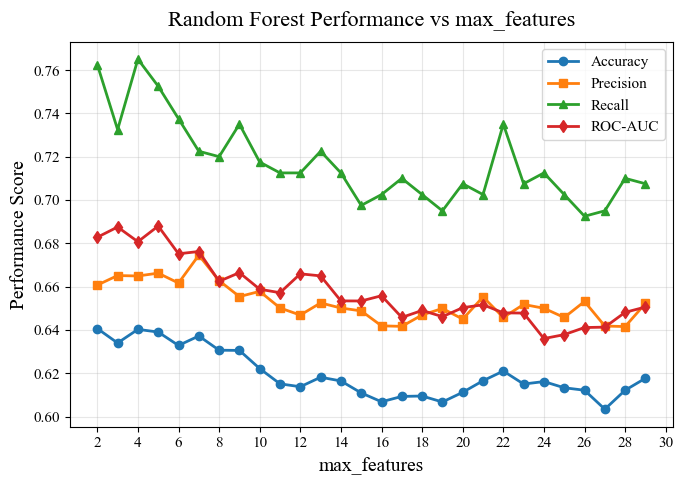

In [16]:
os.makedirs("results",exist_ok=True)

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11
})

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    results_df["max_features"],
    results_df["accuracy"],
    marker="o",
    linewidth=2,
    markersize=6,
    label="Accuracy"
)

ax.plot(
    results_df["max_features"],
    results_df["precision"],
    marker="s",
    linewidth=2,
    markersize=6,
    label="Precision"
)

ax.plot(
    results_df["max_features"],
    results_df["recall"],
    marker="^",
    linewidth=2,
    markersize=6,
    label="Recall"
)

ax.plot(
    results_df["max_features"],
    results_df["roc_auc"],
    marker="d",
    linewidth=2,
    markersize=6,
    label="ROC-AUC"
)

ax.set_xlabel("max_features")
ax.set_ylabel("Performance Score")
ax.set_title("Random Forest Performance vs max_features",pad=12)
ax.set_xticks(range(2, 31, 2))
ax.grid(True, alpha=0.3)
ax.legend(loc="best",frameon=True)
plt.tight_layout()
plt.savefig("./results/rf_performance_vs_max_features.png", dpi=300,bbox_inches="tight")
plt.show()